In [1]:
import os
import sys

# Move up one directory if your notebook is in a subfolder (like 'notebooks')
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image, display
from pathlib import Path

from src.digit_predict import load_model

In [3]:
# Get the project directory (root)
ROOT_DIR = Path.cwd().parent

IMAGE_PATH = ROOT_DIR / "data" / "sudoku.png"

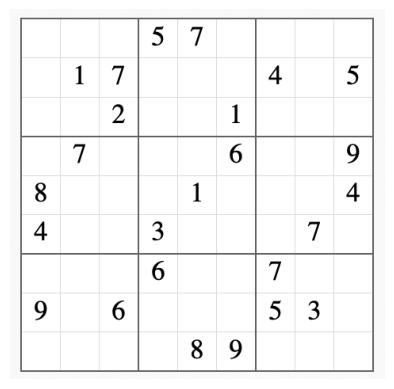

In [4]:

# Import the image and turn into grey scale
img = cv2.imread(IMAGE_PATH)
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(grey, cmap='gray')
plt.axis('off')
plt.show()

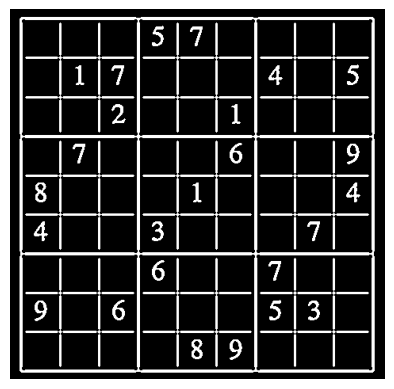

In [5]:
# Apply Gaussian blur effect to remove high frequency noises
blurred = cv2.GaussianBlur(grey, (5, 5), 0)
thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()

In [6]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)
board_contour = contours[0]

# Retrieve the four corners of the board
peri = cv2.arcLength(board_contour, True)
approx = cv2.approxPolyDP(board_contour, 0.02 * peri, True)

if len(approx) != 4:
    raise ValueError("Could not find a 4-sided Sudoku board.")

In [7]:
def sort_corners(pts):
    # Helper to sort points: [top-left, top-right, bottom-right, bottom-left]
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

In [8]:
pts1 = np.float32([pts[0] for pts in approx])
sorted_pts = sort_corners(pts1)
print(sorted_pts)

[[ 14.  10.]
 [459.  12.]
 [457. 458.]
 [ 12. 456.]]


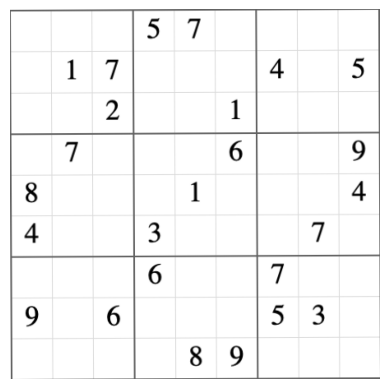

In [9]:
pts2 = np.float32([[0, 0], [450, 0], [450, 450], [0, 450]])
matrix = cv2.getPerspectiveTransform(sorted_pts, pts2)
warped = cv2.warpPerspective(grey, matrix, (450, 450))

plt.imshow(warped, cmap='gray')
plt.axis('off')
plt.show()

In [12]:
grid = []
cell_size = 50  # 450 / 9

MODEL_PATH = ROOT_DIR / "models" / "digit_recognition_model.keras"

model = load_model(MODEL_PATH)

for r in range(9):
    row = []
    for c in range(9):
        # Crop the cell
        x1, y1 = c * cell_size, r * cell_size
        x2, y2 = x1 + cell_size, y1 + cell_size
        cell = warped[y1:y2, x1:x2]

        # Clean cell margins to remove grid border lines
        cell = cell[5:45, 5:45]

        # Check if cell is empty by counting white pixels
        _, thresh_cell = cv2.threshold(cell, 120, 255, cv2.THRESH_BINARY_INV)
        if np.sum(thresh_cell == 255) < 30:  # Adjust threshold based on your image
            row.append(0)  # 0 represents an empty cell
        else:
            # Resize to match model input (e.g., 28x28 for MNIST-like models)
            cell_resized = cv2.resize(thresh_cell, (28, 28))
            cell_input = cell_resized.reshape(1, 28, 28, 1) / 255.0

            # Predict number
            prediction = model.predict(cell_input)
            digit = np.argmax(prediction)
            row.append(int(digit))
    grid.append(row)

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/Users/neil/Develop/SudoVisionCruncher/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [13]:
print("Grid: [")
for row in grid:
    print(f"  {row},")
print("]")

Grid: [
  [0, 0, 0, 5, 7, 0, 0, 0, 0],
  [0, 1, 7, 0, 0, 0, 4, 0, 9],
  [0, 0, 2, 0, 0, 1, 0, 0, 0],
  [0, 7, 0, 0, 0, 6, 0, 0, 4],
  [8, 0, 0, 0, 1, 0, 0, 0, 4],
  [4, 0, 0, 3, 0, 0, 0, 3, 0],
  [0, 0, 0, 6, 0, 0, 1, 0, 0],
  [4, 0, 6, 0, 0, 0, 9, 3, 0],
  [0, 0, 0, 0, 3, 4, 0, 0, 0],
]
